# Task 1: Bank Marketing Prediction
## Introduction

Banks spend millions on marketing campaigns to convince customers to invest in 
term deposits. Not every customer accepts the offer, so predicting who is likely
to subscribe helps banks save money and improve campaign success.

# Problem Statement

A bank wants to identify customers who are likely to subscribe to a term deposit after receiving a marketing campaign.

Instead of contacting every customer, the bank wants to use machine learning to predict potential subscribers and target only those customers.

# Objective

Develop a binary classification model that predicts whether a customer will subscribe to a term deposit.

The model should:

Analyze customer information
Learn patterns from historical data
Predict new customers
Explain predictions using XAI (SHAP/LIME)

# Load Libraries

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# load Data set 
df = pd.read_csv("bank.csv")
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
6,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
7,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
9,28,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes


# Data Cleaning And Understanding

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [4]:
# data statistic description
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [5]:
# check Null Values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [6]:
# check Duplicates 
df.duplicated().sum()

np.int64(0)

In [7]:
# Check Rows And Columns
print("Rows:",df.shape[0],"Columns",df.shape[1])

Rows: 11162 Columns 17


# Data Analysis

In [8]:
# check subscription
df.deposit.value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

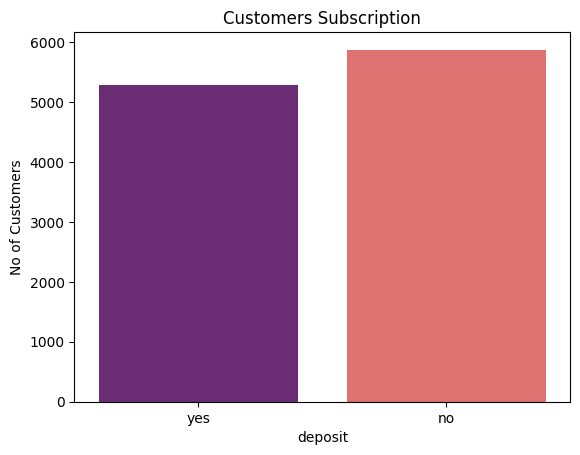

In [9]:
sns.countplot(x=df.deposit,hue = df.deposit,palette="magma")
plt.title("Customers Subscription")
plt.ylabel("No of Customers")
plt.show()

In [10]:
#which Age effect deposit
young_customer = df[
    (df.age > 18) & (df.age < 50)
]

Text(0.5, 1.0, 'Young Custmer Subscription')

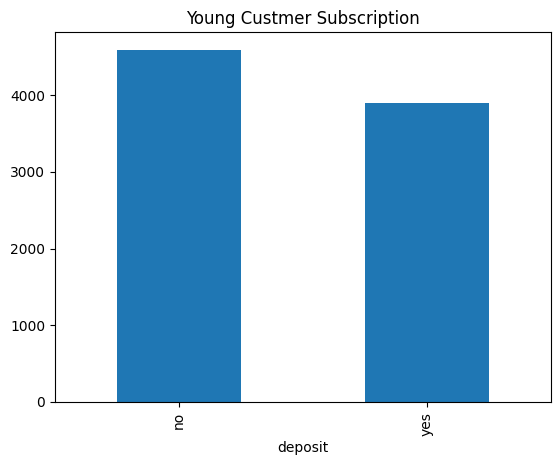

In [11]:
young_customer.deposit.value_counts().plot(kind="bar")
plt.title("Young Custmer Subscription")

In [12]:
# Old Customer Subscription 
old_customer = df[
    (df.age > 50) & (df.age < 100)
]

Text(0.5, 1.0, 'Old Customer Subscription')

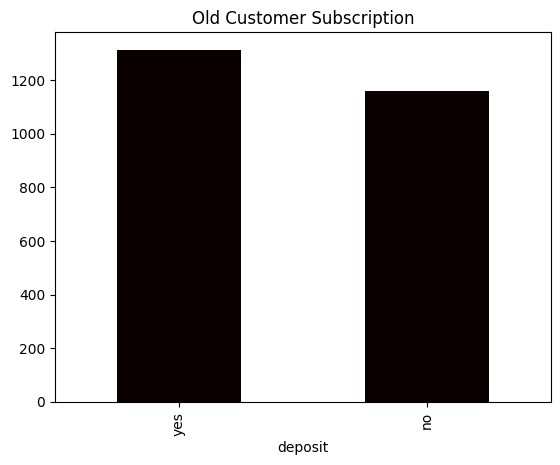

In [13]:
old_customer.deposit.value_counts().plot(kind = "bar",colormap="hot")
plt.title("Old Customer Subscription")

In [14]:
# deposit customer percentage 
deposit_customer = df[df.deposit == "yes"]

In [15]:

deposit_customer.deposit.count()/df.deposit.count()*100

np.float64(47.38398136534671)

In [16]:
# non depositor customer percentage
non_deposit_customer = df[df.deposit == "no"]

In [17]:
non_deposit_customer.deposit.count()/df.deposit.count()*100

np.float64(52.61601863465329)

In [18]:
# mean age value of depositor customer
deposit_age_mean = np.mean(deposit_customer.age)
print("Mean age value of depositor customer",deposit_age_mean)

Mean age value of depositor customer 41.670069956513515


In [19]:
# mean age value of Nondepositor customer
non_deposit_age_mean = np.mean(non_deposit_customer.age)
print("Mean age value of non_depositor customer",non_deposit_age_mean)

Mean age value of non_depositor customer 40.83739145240933


In [20]:
# Check deposit Customers are Educated or not
df.education.value_counts()

education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

Text(0.5, 1.0, 'Education Rate deposit Customer')

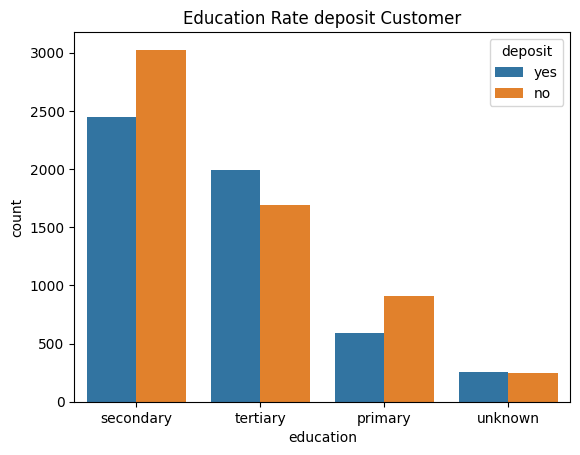

In [21]:
sns.countplot(x=df.education,hue=df.deposit,fill=True)
plt.title("Education Rate deposit Customer")

In [22]:
# Check Balance effect deposit
df.balance

0        2343
1          45
2        1270
3        2476
4         184
         ... 
11157       1
11158     733
11159      29
11160       0
11161       0
Name: balance, Length: 11162, dtype: int64

In [23]:
# Average Balance of the depositor and non depositor customer 
avg_bal = df.groupby("deposit")["balance"].mean()
print("Average Balance of Subscriber Or Non subscriber:",avg_bal)

Average Balance of Subscriber Or Non subscriber: deposit
no     1280.227141
yes    1804.267915
Name: balance, dtype: float64


<Axes: title={'center': 'Outliers In the Balance'}, xlabel='balance'>

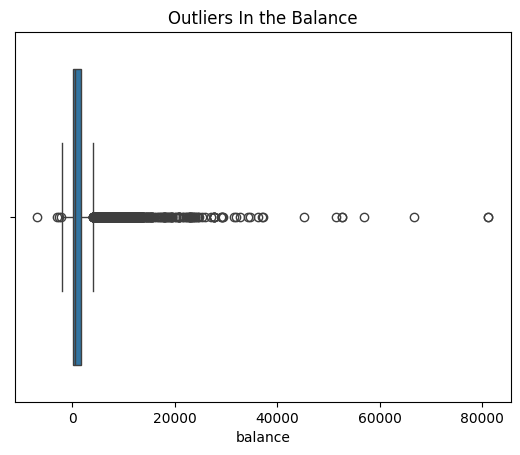

In [24]:
# check Outliers in the Balance 
plt.title("Outliers In the Balance")
sns.boxplot(df.balance,orient="h")

Text(0.5, 1.0, 'Loan wise Subcription')

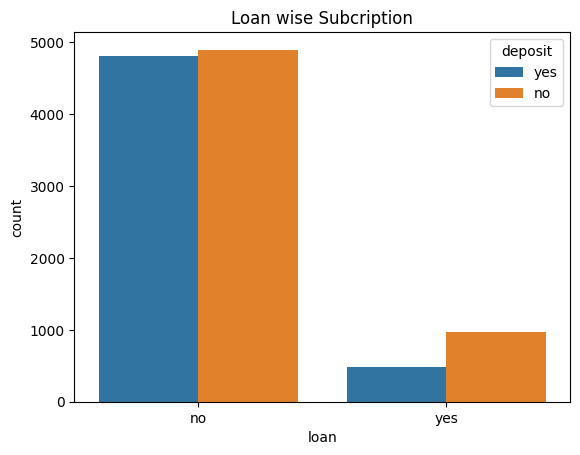

In [25]:
# check loan subscriber 
sns.countplot(x=df.loan,hue=df.deposit,)
plt.title("Loan wise Subcription")

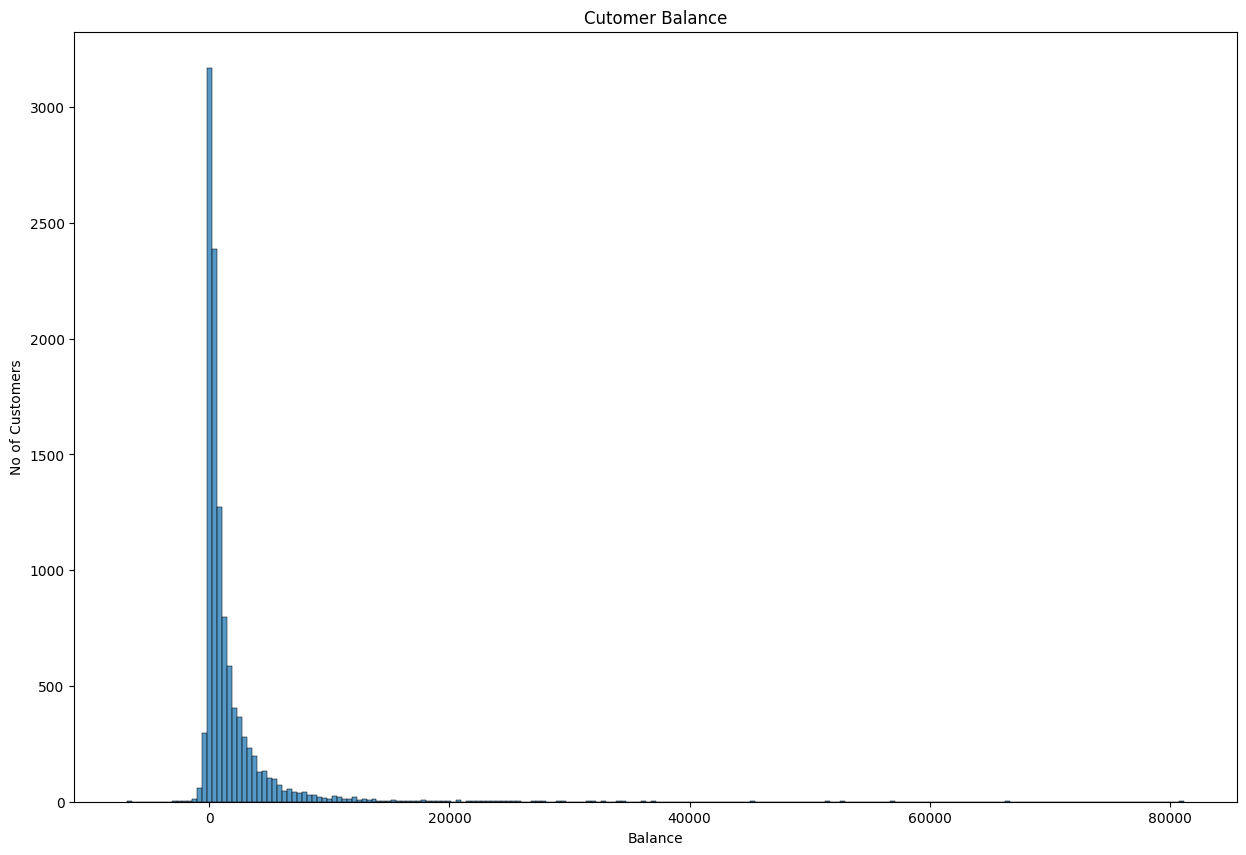

In [26]:
plt.figure(figsize=(15,10))
sns.histplot(df.balance)
plt.title("Cutomer Balance")
plt.xlabel("Balance")
plt.ylabel("No of Customers")
plt.show()

In [27]:
# check Wich Job effect subscription
df.job.value_counts()


job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

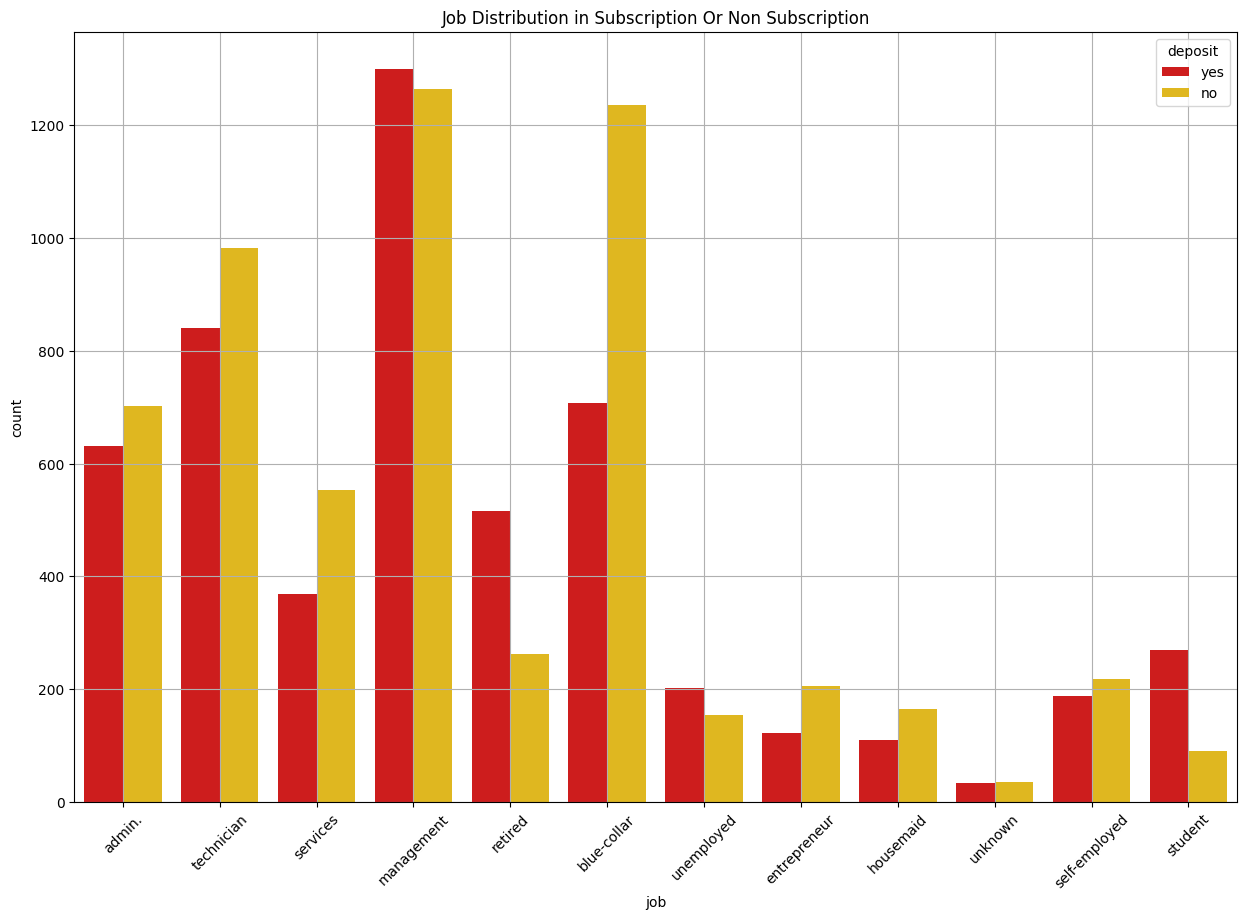

In [28]:
plt.figure(figsize=(15,10))
sns.countplot(x=df.job,hue=df.deposit,palette="hot",orient="y")
plt.title("Job Distribution in Subscription Or Non Subscription")
plt.xticks(rotation = 45)
plt.grid()
plt.show()


In [29]:
# which Month Most Subscription
df.month.value_counts()

month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
mar     276
dec     110
Name: count, dtype: int64

<Axes: xlabel='deposit'>

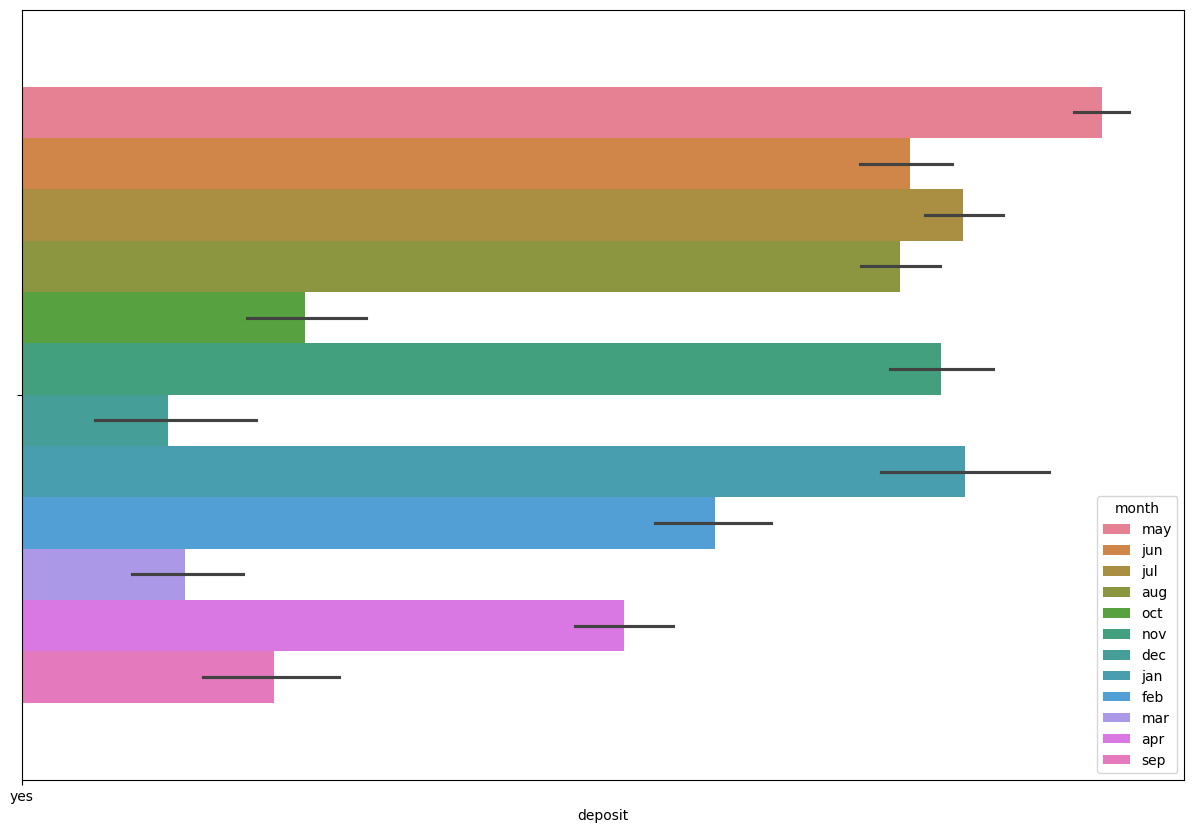

In [30]:
plt.figure(figsize=(15,10))
sns.barplot(x=df.deposit,hue=df.month,orient="h")

# Data Preprocessing 

In [31]:
df.deposit = df.deposit.replace({"yes":1,"no":0}).astype("int64")

In [32]:
# Check Correlation Graph 
cor_relation = df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous','deposit']].corr()

Text(0.5, 1.0, 'Correlation Graph With Numerical Variables')

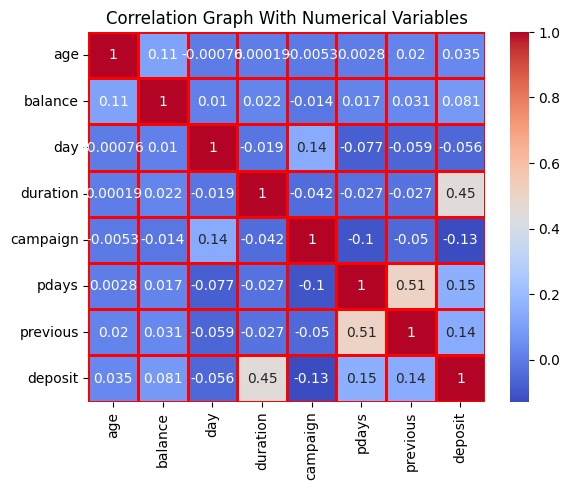

In [33]:
sns.heatmap(cor_relation,annot=True,cmap="coolwarm",linecolor="r",linewidths=2)
plt.title("Correlation Graph With Numerical Variables")

# Model Training

In [34]:
# import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [35]:
# X input 
x=df.drop(["deposit"],axis=1)

In [36]:
# Out put Target varible 
y = df["deposit"]

# Train Test Split

In [37]:
x_train,X_test,y_train,y_test = train_test_split(x,y,random_state=108,test_size=0.2,stratify=y)

In [38]:
# select Catagorical variable 
cata_var = x_train.select_dtypes(include=("object","str")).columns.tolist()
cata_var

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [39]:
num_var = x_train.select_dtypes(include=["int64","float64"]).columns.tolist()
num_var

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [40]:
prerocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),num_var),
        ("cat",OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False),cata_var)
    ],
    remainder="drop"
)

# Pipe Line

In [41]:
pipeline = Pipeline([
    ("prep",prerocessor),
    ("clf",LogisticRegression(class_weight="balanced",max_iter=1000))
])

In [42]:
pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [43]:
y_pred = pipeline.predict(X_test)

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85      1175
           1       0.84      0.83      0.83      1058

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233



In [45]:
confusion_matrix(y_test,y_pred)

array([[1008,  167],
       [ 184,  874]])

In [46]:
pipeline.score(X_test,y_test)

0.8428123600537394

In [47]:
print("Training Accuracy:", pipeline.score(x_train,y_train))
print("Testing Accuracy:", pipeline.score(X_test, y_test))

Training Accuracy: 0.8256243700302386
Testing Accuracy: 0.8428123600537394


# Model Evalution

In [48]:
# for other Models
models = {
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=300,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"),

    "Gaussian NB": GaussianNB(),

    "XGBoost": XGBClassifier( n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42),

    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [49]:
# see all Models with their Accuracy score 
for name,model in models.items():
    pipeline = Pipeline([
        ("prep",prerocessor),
        ("model",model)
    ])
    pipeline.fit(x_train,y_train)
     
    print(f"************* Model Name: {name} ******************")
    y_pred = pipeline.predict(X_test)
    print("classification report:",classification_report(y_test,y_pred))
    print("Confusion Matrix: ",confusion_matrix(y_test,y_pred))
    print("Training Accuracy:", pipeline.score(x_train,y_train))
    print("Testing Accuracy:", pipeline.score(X_test, y_test))
    print("******Accuracy Rate*******")
    print(f"Accuracy of {name} : ",pipeline.score(X_test,y_test))
    

************* Model Name: Decision Tree ******************
classification report:               precision    recall  f1-score   support

           0       0.88      0.76      0.82      1175
           1       0.77      0.89      0.82      1058

    accuracy                           0.82      2233
   macro avg       0.83      0.82      0.82      2233
weighted avg       0.83      0.82      0.82      2233

Confusion Matrix:  [[898 277]
 [121 937]]
Training Accuracy: 0.8362638593347519
Testing Accuracy: 0.8217644424540976
******Accuracy Rate*******
Accuracy of Decision Tree :  0.8217644424540976
************* Model Name: Random Forest ******************
classification report:               precision    recall  f1-score   support

           0       0.90      0.84      0.87      1175
           1       0.83      0.90      0.86      1058

    accuracy                           0.87      2233
   macro avg       0.87      0.87      0.87      2233
weighted avg       0.87      0.87      0.87  

In [50]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
results = []

In [51]:
for name,model in models.items():
    pipeline = Pipeline([
        ("prep",prerocessor),
        ("model",model)
    ])
    
    pipeline.fit(x_train,y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1     = f1_score(y_test,y_pred)

    y_prob = pipeline.predict_proba(X_test)[:,1]
    roc  = roc_auc_score(y_test,y_prob)

    results.append({
        "Model_name":name,
        "Accuracy Score":accuracy,
        "Precision":precision,
        "Recall Score":recall,
        "f1_score":f1,
        "roc_auc_score":roc
    })



In [52]:
# see results each model 
df_results_model = pd.DataFrame(results)

##################### for accuracy make sort values 
df_results_model.sort_values(by="f1_score",ascending=False)

,Model_name,Accuracy Score,Precision,Recall Score,f1_score,roc_auc_score
1,Random Forest,0.865204,0.831727,0.896975,0.863120,0.927722
3,XGBoost,0.866995,0.843102,0.883743,0.862944,0.934396
4,SVM,0.860278,0.835432,0.878072,0.856221,0.925370
0,Decision Tree,0.821764,0.771829,0.885633,0.824824,0.895978
5,KNN,0.817286,0.821782,0.784499,0.802708,0.882452
2,Gaussian NB,0.718764,0.820896,0.519849,0.636574,0.823959


# Choose Best Model  

In [53]:
random_forest = Pipeline([
    ("prep",prerocessor),
    ("model",RandomForestClassifier(class_weight="balanced",n_estimators=300))
])

In [54]:
random_forest.fit(x_train,y_train)
r_f_pred = random_forest.predict(X_test)

print("Accuracy",accuracy_score(y_test,r_f_pred))


Accuracy 0.8687863860277654


# Shap Explaination

In [55]:
import shap as shape_explainer

In [56]:
# select model
r_f_model = random_forest.named_steps["model"]

In [57]:
# transform x_train and x_test
x_train_transform = random_forest.named_steps["prep"].transform(x_train)
x_test_transform = random_forest.named_steps["prep"].transform(X_test)

In [58]:
feature_name = random_forest.named_steps["prep"].get_feature_names_out()

In [59]:
x_test_shape = pd.DataFrame(x_test_transform,columns=feature_name)
x_test_sample = x_test_shape.sample(n=100, random_state=42)
x_test_sample.head()

,num__age,num__balance,num__day,num__duration,num__campaign,num__pdays,num__previous,cat__job_blue-collar,cat__job_entrepreneur,cat__job_housemaid,...,cat__month_jul,cat__month_jun,cat__month_mar,cat__month_may,cat__month_nov,cat__month_oct,cat__month_sep,cat__poutcome_other,cat__poutcome_success,cat__poutcome_unknown
1034,1.237715,-0.311331,-1.269810,-0.431087,-0.578267,1.089438,0.981456,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
426,3.083249,0.492654,0.514262,-0.055427,0.184076,-0.481480,-0.370298,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
482,2.831585,0.660114,-0.080429,-0.535115,-0.578267,1.200327,0.530871,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
755,0.734388,-0.343752,0.514262,0.999309,-0.197096,-0.481480,-0.370298,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
445,-0.104491,-0.093306,0.633200,-0.925223,-0.197096,-0.481480,-0.370298,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [60]:
explainer = shape_explainer.TreeExplainer(r_f_model)

In [ ]:
shape_values = explainer(x_test_sample)

.values =
array([[[ 0.02588624, -0.02588624],
        [ 0.01341091, -0.01341091],
        [ 0.01193676, -0.01193676],
        ...,
        [-0.00067341,  0.00067341],
        [ 0.05526313, -0.05526313],
        [-0.03602312,  0.03602312]],

       [[-0.13074094,  0.13074094],
        [-0.0389206 ,  0.0389206 ],
        [-0.00690799,  0.00690799],
        ...,
        [-0.00022728,  0.00022728],
        [ 0.01342291, -0.01342291],
        [ 0.00899706, -0.00899706]],

       [[-0.03213278,  0.03213278],
        [-0.01143117,  0.01143117],
        [-0.00199469,  0.00199469],
        ...,
        [-0.00014546,  0.00014546],
        [-0.09829307,  0.09829307],
        [-0.03868373,  0.03868373]],

       ...,

       [[ 0.02208461, -0.02208461],
        [-0.0598221 ,  0.0598221 ],
        [ 0.06361106, -0.06361106],
        ...,
        [ 0.00042906, -0.00042906],
        [ 0.02452589, -0.02452589],
        [ 0.01678134, -0.01678134]],

       [[ 0.0118792 , -0.0118792 ],
        [ 0.01844

In [66]:
print(shape_values)

.values =
array([[[ 0.02588624, -0.02588624],
        [ 0.01341091, -0.01341091],
        [ 0.01193676, -0.01193676],
        ...,
        [-0.00067341,  0.00067341],
        [ 0.05526313, -0.05526313],
        [-0.03602312,  0.03602312]],

       [[-0.13074094,  0.13074094],
        [-0.0389206 ,  0.0389206 ],
        [-0.00690799,  0.00690799],
        ...,
        [-0.00022728,  0.00022728],
        [ 0.01342291, -0.01342291],
        [ 0.00899706, -0.00899706]],

       [[-0.03213278,  0.03213278],
        [-0.01143117,  0.01143117],
        [-0.00199469,  0.00199469],
        ...,
        [-0.00014546,  0.00014546],
        [-0.09829307,  0.09829307],
        [-0.03868373,  0.03868373]],

       ...,

       [[ 0.02208461, -0.02208461],
        [-0.0598221 ,  0.0598221 ],
        [ 0.06361106, -0.06361106],
        ...,
        [ 0.00042906, -0.00042906],
        [ 0.02452589, -0.02452589],
        [ 0.01678134, -0.01678134]],

       [[ 0.0118792 , -0.0118792 ],
        [ 0.01844

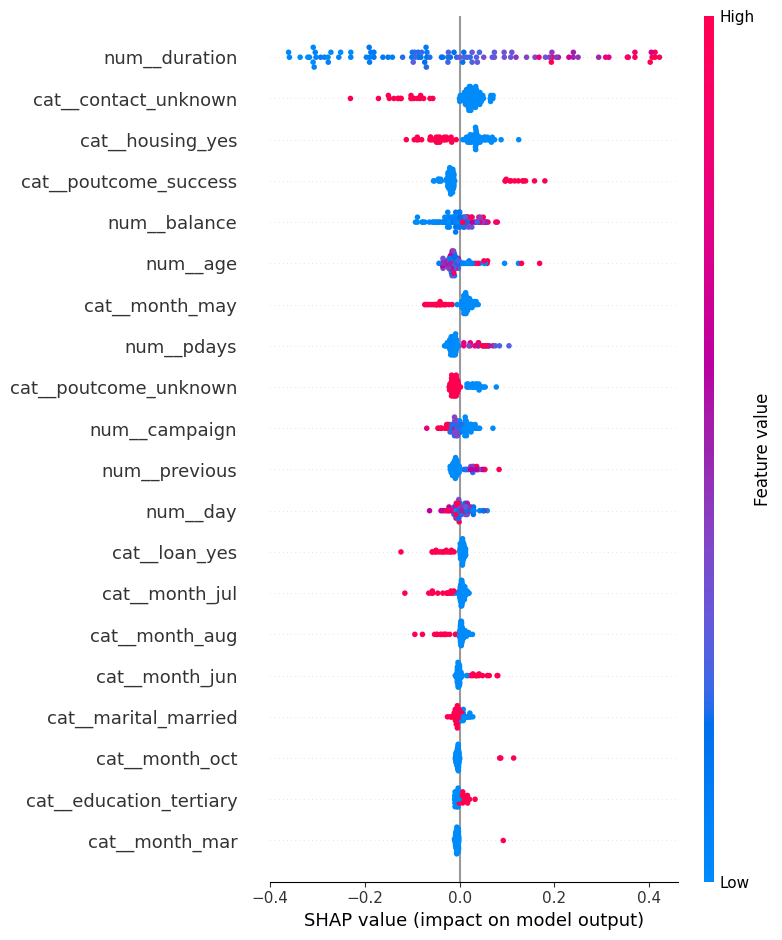

In [67]:
shape_explainer.summary_plot(shape_values[:,:,1],x_test_sample)

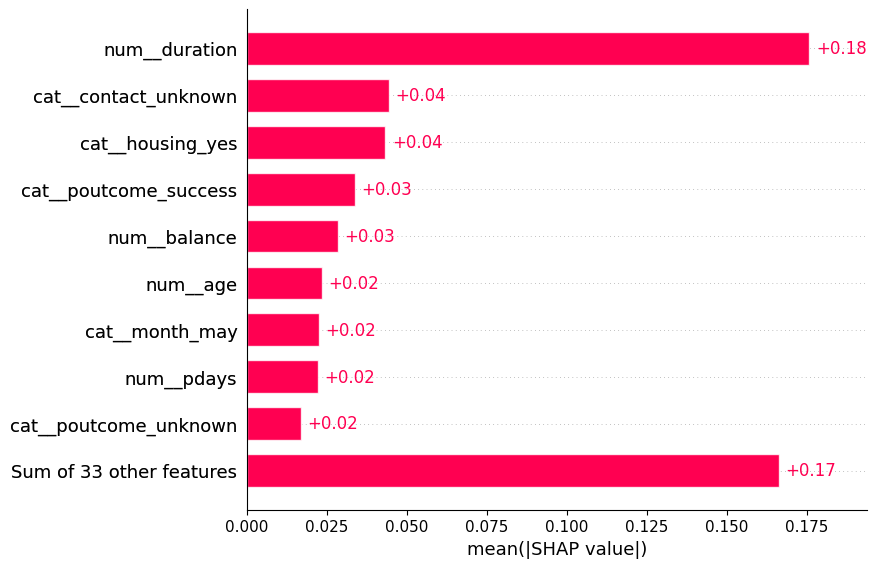

In [ ]:
# explain Why Model predict Deposit
shape_explainer.plots.bar(shape_values[:,:,1])

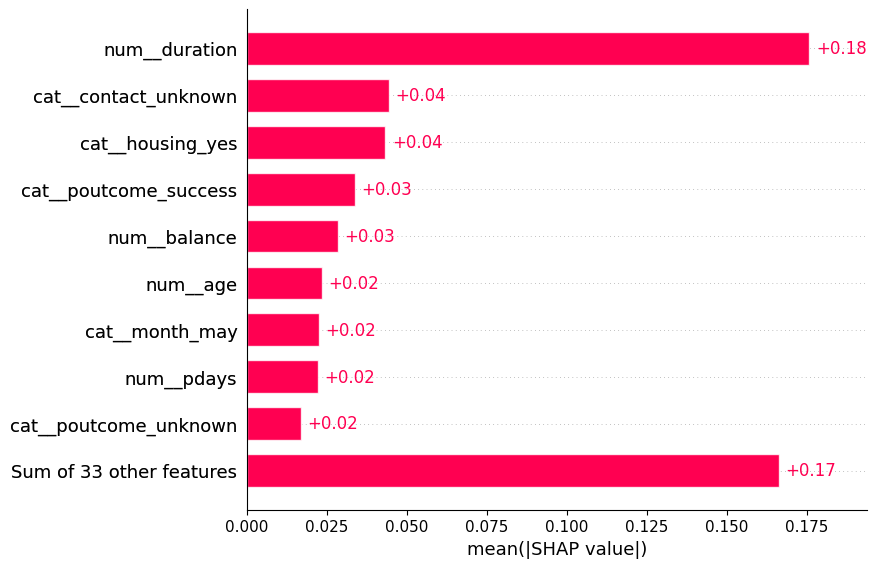

In [70]:
# explain Why Model predict not  Deposit
shape_explainer.plots.bar(shape_values[:,:,0])

SHAP analysis was performed to explain the predictions of the Random Forest classifier. 
The summary plot revealed that call duration (duration) was the most influential feature 
affecting customer subscription predictions.
Customers with longer call durations generally had a higher probability of subscribing to a term deposit.
 Other important features included contact type, housing loan status, previous campaign outcome, and account balance.
 Customers with successful previous marketing interactions and higher account balances were more likely to subscribe,
  whereas an unknown contact type or having a housing loan generally reduced the likelihood of subscription.
  These explanations improve the transparency and trustworthiness of the model by showing how individual features influence predictions.

# Save Model


In [71]:
import joblib

In [72]:
joblib.dump(random_forest,"bank_marketing_pipeline.pkl")

['bank_marketing_pipeline.pkl']